#Import modules

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import seaborn as sns

#Data

In [3]:
embeddings = pd.read_csv('drive/My Drive/Colab Notebooks/Deep_learning_metabolomics_prediction/BulkRNABert_data/bulkrnabert_embeddings.csv', index_col=0)
print(embeddings.shape)
embeddings

(442, 256)


,0,1,2,3,4,5,6,7,8,9,...,246,247,248,249,250,251,252,253,254,255
MSKC-00397,0.913342,0.621870,0.922743,-1.037893,0.301553,0.715152,0.206450,0.652923,0.059982,0.294590,...,0.175746,-0.133243,0.109954,0.040338,0.067777,1.130643,0.370476,0.344561,-0.118917,0.710770
MSKC-00399,0.818992,0.296598,0.773417,-0.866102,0.307585,0.849735,0.420930,0.668587,-0.094435,-0.175127,...,0.098970,-0.331284,0.045357,-0.092454,-0.062354,1.144853,0.325433,0.280668,-0.220902,0.927439
MSKC-00400,1.022584,0.321305,1.228209,-1.065100,0.499109,0.576022,0.248522,0.579413,-0.226993,0.099416,...,-0.146370,-0.176852,-0.045236,-0.197819,-0.038868,1.062385,0.275921,0.211972,-0.131308,0.676849
MSKC-00404,1.022246,0.744968,1.156375,-1.013309,0.230046,0.506557,0.223892,0.750233,0.054625,0.459118,...,0.257191,-0.178159,0.146739,-0.014896,0.050930,1.156376,0.497806,0.327070,-0.180218,0.540008
MSKC-00405,0.971925,0.678423,0.743625,-1.148056,0.332629,0.655422,0.190903,0.555662,0.075683,0.220108,...,0.057747,-0.262169,-0.035882,-0.028639,0.074571,1.213970,0.348896,0.325905,-0.168206,0.697458
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
PT-P44H,0.533675,-0.316429,3.371898,-0.029202,1.088933,0.488736,-0.090113,0.487655,-0.186383,0.200859,...,0.820505,-0.337173,0.678901,-0.616893,-0.337793,0.528891,0.194825,-0.301103,0.193381,0.732298
PT-R55F,0.582715,-0.349183,3.070900,-0.071421,0.945457,0.581417,0.043929,0.615177,-0.309759,0.207503,...,0.907579,-0.257814,0.802587,-0.588829,-0.070505,0.612147,0.205887,-0.325677,0.269320,0.858617
PT-RN5K,0.562467,-0.276826,3.437461,-0.140747,1.013584,0.594322,-0.079603,0.749423,-0.308488,0.279132,...,0.957076,-0.202017,0.776208,-0.609761,-0.075496,0.633105,0.102027,-0.451013,0.353921,0.800787
PT-UTHO,0.593032,-0.350178,2.716498,-0.164287,0.824521,0.557042,0.101592,0.653268,-0.325775,0.185995,...,0.867591,-0.184794,0.821017,-0.624438,-0.057503,0.671240,0.301893,-0.214687,0.284997,0.922281


In [4]:
metabolites = pd.read_csv('drive/My Drive/Colab Notebooks/Metabolite_prediction_ML/metabolomics_log2.csv', index_col = 0)
metabolites = metabolites.T
metabolites = metabolites.loc[embeddings.index]
threshold = 0.2
nan_percentage = metabolites.isnull().mean()
filtered_metabolites = metabolites.loc[:, nan_percentage <= threshold]
metabolites = filtered_metabolites
print(metabolites.shape)
metabolites.head(3)

(442, 218)


,"1,5-anhydroglucitol (1,5-AG)",1-arachidonoyl-GPC (20:4n6),1-arachidonoyl-GPE (20:4n6),1-arachidonoyl-GPI (20:4),1-linoleoylglycerol (18:2),1-linoleoyl-GPC (18:2),1-oleoylglycerol (1-monoolein),1-oleoyl-GPE (18:1),1-palmitoleoyl-GPC (16:1),1-palmitoylglycerol (1-monopalmitin),...,urea,uridine,valine,valylglycine,xanthine,xanthosine,3-phosphoglycerate,dehydroascorbate,pyruvate,phosphoenolpyruvate (PEP)
MSKC-00397,22.151250,18.354985,22.463941,20.468435,21.777534,22.886951,21.766380,23.556862,20.373682,22.047978,...,25.553784,23.658074,28.487968,16.955614,24.833037,18.604157,23.239660,15.840222,17.228723,22.396280
MSKC-00399,21.247188,18.111536,22.645598,20.529346,19.739271,21.009891,20.167228,21.002270,18.394891,21.123958,...,24.359559,26.169329,28.564088,16.955614,24.448438,20.819139,24.725409,18.565178,18.696191,23.682378
MSKC-00400,21.760056,15.625641,19.476107,19.097750,18.660445,20.936016,18.433717,18.995415,18.660803,19.339385,...,26.413287,27.040641,28.949443,16.955614,26.111056,19.417787,22.856360,23.065816,17.490103,21.785170


#Log2 transformation

In [5]:
embeddings = embeddings.apply(lambda x: np.log2(x + 1))
embeddings.head(3)

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)


,0,1,2,3,4,5,6,7,8,9,...,246,247,248,249,250,251,252,253,254,255
MSKC-00397,0.936094,0.697658,0.943166,NaN,0.380234,0.778337,0.270768,0.725019,0.084039,0.372495,...,0.233577,-0.206301,0.150500,0.057053,0.094610,1.091289,0.454677,0.427135,-0.182651,0.774646
MSKC-00399,0.863139,0.374732,0.826532,-2.900795,0.386905,0.887319,0.506836,0.738627,-0.143111,-0.277756,...,0.136152,-0.580535,0.063996,-0.139958,-0.092884,1.100879,0.406464,0.356896,-0.360123,0.946685
MSKC-00400,1.016199,0.401963,1.155884,NaN,0.584105,0.656288,0.320221,0.659389,-0.371447,0.136738,...,-0.228318,-0.280776,-0.066783,-0.318000,-0.057193,1.044314,0.351539,0.277356,-0.203084,0.745753


#Data shuffling

In [6]:
combined_data = pd.concat([embeddings, metabolites], axis=1)
shuffled_data = combined_data.sample(frac=1, random_state=0)
shuffled_embeddings = shuffled_data[embeddings.columns]
shuffled_metabolites = shuffled_data[metabolites.columns]

embeddings = shuffled_embeddings
metabolites = shuffled_metabolites

#Data imputation and normalization [-1, 1]

In [140]:
np.min(metabolites)

0.0

In [141]:
metabolites.min().min()

0.0

In [142]:
metabolites  = metabolites.fillna(0)

In [143]:
from sklearn.impute import SimpleImputer

def impute_normalize(df):
  data = df.copy()
  imputer = SimpleImputer(strategy='median')
  data = imputer.fit_transform(data)
  min_val = np.min(data)
  max_val = np.max(data)
  data_scaled = 2 * ((data - min_val) / (max_val - min_val)) - 1
  data_scaled = data_scaled.astype(np.float32)
  print('min:', np.min(data_scaled))
  print('max:', np.max(data_scaled))
  print('shape:', data_scaled.shape)

  return data_scaled

In [144]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(embeddings, metabolites, test_size = 0.2, random_state = 0)

X_train = impute_normalize(X_train)
X_test = impute_normalize(X_test)

print('Train data:')
print(X_train.shape)
print(y_train.shape)

print('Test data:')
print(X_test.shape)
print(y_test.shape)

min: -1.0
max: 1.0
shape: (353, 252)
min: -1.0
max: 1.0
shape: (89, 252)
Train data:
(353, 252)
(353, 218)
Test data:
(89, 252)
(89, 218)


/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['13' '99' '128' '202']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/impute/_base.py:635: UserWarning: Skipping features without any observed values: ['13' '99' '128' '202']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


In [145]:
X_train

array([[0.6789105 , 0.58577365, 0.79972607, ..., 0.594611  , 0.6541642 ,
        0.6906701 ],
       [0.72356796, 0.6714879 , 0.7266238 , ..., 0.628994  , 0.58131933,
        0.6667471 ],
       [0.7256108 , 0.6811002 , 0.6512204 , ..., 0.66346395, 0.6113342 ,
        0.70679724],
       ...,
       [0.70744425, 0.6446327 , 0.71668786, ..., 0.65312105, 0.5674259 ,
        0.6973386 ],
       [0.71800596, 0.669273  , 0.65069264, ..., 0.6614295 , 0.61278677,
        0.71170884],
       [0.72188145, 0.6675485 , 0.73206526, ..., 0.61519516, 0.5845901 ,
        0.670413  ]], dtype=float32)

#Import sklearn modules

In [23]:
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.compose import TransformedTargetRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge
from sklearn.linear_model import MultiTaskLasso
from sklearn.linear_model import MultiTaskElasticNet
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

#Scoring and plotting functions

In [90]:
results_path = ''

In [91]:
from sklearn.metrics import r2_score, mean_squared_error

def get_r2_mse_rmse_plot_pred(data_y_test, model_predictions, model_type):

  r2 = r2_score(data_y_test, model_predictions)
  mse = mean_squared_error(data_y_test, model_predictions)
  rmse = mse**0.5

  print(f"R-squared: {r2}")
  print(f"Mean Squared Error (MSE): {mse}")
  print(f"Root Mean Squared Error (RMSE): {rmse}")


  plt.figure(figsize=(8, 6))
  for i in range(data_y_test.shape[1]):
      plt.scatter(data_y_test.iloc[:, i], model_predictions[:, i], alpha=0.5)

  plt.plot([data_y_test.min().min(), data_y_test.max().max()], [data_y_test.min().min(), data_y_test.max().max()], 'k--', lw=2, label='Ideal')

  plt.xlabel("Actual Values")
  plt.ylabel("Predicted Values")
  plt.title(f"Predicted vs. Actual Values for Metabolites ({model_type})")
  plt.legend(bbox_to_anchor=(1.05, 1), loc='upper right')
  plt.grid(True)
  # plt.savefig(f'{results_path}/{model_type}.svg', bbox_inches = 'tight')
  plt.show()

In [92]:
from sklearn.model_selection import cross_val_score

def plot_cv_scores(model_pipeline, model_type,cv_fold):

  imputer_metabolites = SimpleImputer(strategy='mean')
  metabolites_imputed = imputer_metabolites.fit_transform(metabolites)
  metabolites_imputed = pd.DataFrame(metabolites_imputed, columns=metabolites.columns, index=metabolites.index)

  scores = cross_val_score(model_pipeline, embeddings, metabolites_imputed, cv=cv_fold, scoring='neg_mean_squared_error', n_jobs = -1)

  print("Cross-validation scores:", scores)
  print("Average score:", scores.mean())

  scores = pd.DataFrame(scores)
  scores = scores.rename(columns = {0: 'Cross-validation scores'})
  scores['Cross-validation fold'] = [i + 1 for i in range(len(scores))]

  sns.lineplot(data = scores, x = 'Cross-validation fold', y = 'Cross-validation scores')
  plt.ylabel('Negative MSE')
  plt.title('Negative MSE fluctuation with CV-fold')
  plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
  # plt.savefig(f'{results_path}/MSE vs CV ({model_type}).svg', bbox_inches = 'tight')
  plt.show()

In [93]:
from sklearn.model_selection import KFold

def get_r2_cross_val(model, model_name):

  cv = KFold(n_splits=10, shuffle=True, random_state=0)

  scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='r2', n_jobs = -1)

  print("Cross-validation R-squared scores:", scores)
  print("Average R-squared score:", scores.mean())

  scores_df = pd.DataFrame({'Fold': range(1, len(scores) + 1), 'R-squared': scores})

  # Plot the scores
  plt.figure(figsize=(8, 6))
  sns.lineplot(x='Fold', y='R-squared', data=scores_df, marker='o')
  plt.title(f'Cross-validation R-squared scores for {model_name}')
  plt.xlabel('Fold')
  plt.ylabel('R-squared')
  # plt.savefig(f'{results_path}/R2 vs CV ({model_name}).svg', bbox_inches = 'tight')
  plt.show()

In [94]:
from sklearn.metrics import mean_squared_error

def get_metrics(y_predicted):

  mse = mean_squared_error(y_test, y_predicted)
  print("MSE:", mse)

  from sklearn.metrics import mean_absolute_error
  mae = mean_absolute_error(y_test, y_predicted)
  print("MAE:", mae)

  from sklearn.metrics import median_absolute_error
  medae = median_absolute_error(y_test, y_predicted,)
  print("MedAE:", medae)

  def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

  mape = mean_absolute_percentage_error(y_test, y_predicted)
  print('Mean absolute percentage error:', mape)

In [95]:
from scipy.stats import spearmanr

def get_spearman_correlation(model_predictions, model_name):

  correlation, p_value = spearmanr(X_test, model_predictions)

  correlation_df = pd.DataFrame({'Actual': y_test.values.flatten(), 'Predicted': model_predictions.flatten()})

  # Calculate Spearman's correlation
  correlation, p_value = spearmanr(correlation_df['Actual'], correlation_df['Predicted'])

  # Add correlation and p-value to DataFrame
  correlation_df['Correlation'] = correlation
  correlation_df['P-value'] = p_value

  sns.regplot(x='Actual', y='Predicted', data=correlation_df, line_kws={'color': 'red'})
  plt.title(f'Spearman\'s Correlation ({model_name})')
  plt.xlabel('Actual Values')
  plt.ylabel('Predicted Values')

  # Add correlation and p-value as text
  plt.text(0.1, 0.9, f'Correlation: {correlation:.2f}\nP-value: {p_value:.2f}', transform=plt.gca().transAxes)
  # plt.savefig(f'{results_path}/Spearmans Corr ({model_name}).svg', bbox_inches = 'tight')
  plt.show()

In [96]:
#Checking for heteroscedasticity
!pip install statsmodels

import statsmodels.api as sm

def get_residuals_vs_pred_plot(model_predictions, model_name):

  residuals = (y_test - model_predictions).values.ravel()

  plt.figure(figsize=(8, 6))
  plt.scatter(model_predictions.ravel(), residuals, alpha=0.6)
  plt.axhline(y=0, color='red', linestyle='--', linewidth=1)
  plt.title(f"Residuals vs. Predicted Values ({model_name})")
  plt.xlabel("Predicted Values")
  plt.ylabel("Residuals")
  # plt.savefig(f'{results_path}/Residuals vs Pred Values ({model_name}).svg', bbox_inches = 'tight')
  plt.show()

In [97]:
def plot_r2_per_metabolite(model, model_name, X_test, y_test):
    """Plots the R2 score per metabolite for a given model in descending order."""

    y_pred = model.predict(X_test)  # Get model predictions

    r2_scores = []  # Initialize list to store R2 scores
    for i in range(y_test.shape[1]):  # Iterate through each metabolite (column)
        r2 = r2_score(y_test.iloc[:, i], y_pred[:, i])  # Calculate R2 for the current metabolite
        r2_scores.append(r2)  # Add the R2 score to the list

    # Create a DataFrame for sorting
    r2_df = pd.DataFrame({'Metabolite': y_test.columns, 'R2 Score': r2_scores})

    # Sort the DataFrame by R2 scores in descending order
    r2_df = r2_df.sort_values(by=['R2 Score'], ascending=False)

    # Plotting
    plt.figure(figsize=(10, 6))  # Adjust figure size as needed
    plt.bar(range(len(r2_df)), r2_df['R2 Score'])  # Create bar plot of R2 scores
    plt.xticks()  # Set x-axis labels to metabolite names
    plt.xlabel("Metabolite")
    plt.ylabel("R2 Score")
    plt.title(f"R2 Score per Metabolite ({model_name}) - Descending Order")
    plt.tight_layout()  # Adjust layout to prevent labels from overlapping
    # plt.savefig(f'{results_path}/R2 per metabolite ({model_name}).svg', bbox_inches = 'tight')
    plt.show()

In [98]:
def get_r2_per_metabolite(model, model_name, X_test, y_test):
    """Get the R2 score per metabolite for a given model in descending order."""

    y_pred = model.predict(X_test)  # Get model predictions

    r2_scores = []  # Initialize list to store R2 scores
    for i in range(y_test.shape[1]):  # Iterate through each metabolite (column)
        r2 = r2_score(y_test.iloc[:, i], y_pred[:, i])  # Calculate R2 for the current metabolite
        r2_scores.append(r2)  # Add the R2 score to the list

    # Create a DataFrame for sorting
    r2_df = pd.DataFrame({'Metabolite': y_test.columns, 'R2 Score': r2_scores})

    # Sort the DataFrame by R2 scores in descending order
    r2_df = r2_df.sort_values(by=['R2 Score'], ascending=False)

    return r2_df

In [99]:
from scipy.stats import spearmanr

def plot_spearman_per_metabolite(model, model_name, X_test, y_test):
    """Plots the Spearman's correlation coefficient per metabolite for a given model."""

    y_pred = model.predict(X_test)  # Get model predictions

    spearman_coeffs = []  # Initialize list to store Spearman's coefficients
    for i in range(y_test.shape[1]):  # Iterate through each metabolite (column)
        coeff, _ = spearmanr(y_test.iloc[:, i], y_pred[:, i])  # Calculate Spearman's coefficient
        spearman_coeffs.append(coeff)  # Add the coefficient to the list

    # Create a DataFrame for sorting
    spearman_df = pd.DataFrame({'Metabolite': y_test.columns, 'Spearman Coefficient': spearman_coeffs})

    # Sort the DataFrame by Spearman's coefficients in descending order
    spearman_df = spearman_df.sort_values(by=['Spearman Coefficient'], ascending=False)

    # Plotting
    plt.figure(figsize=(10, 6))  # Adjust figure size as needed
    plt.bar(range(len(spearman_df)), spearman_df['Spearman Coefficient'])  # Create bar plot of coefficients
    plt.xticks()  # Set x-axis labels to metabolite names
    plt.xlabel("Metabolite")
    plt.ylabel("Spearman's Coefficient")
    plt.title(f"Spearman's Correlation Coefficient per Metabolite ({model_name}) - Descending Order")
    plt.tight_layout()  # Adjust layout to prevent labels from overlapping
    # plt.savefig(f'{results_path}/Spearman per metabolite ({model_name}).svg', bbox_inches = 'tight')
    plt.show()

In [100]:
def get_spearman_per_metabolite(model, model_name, X_test, y_test):
    """Get the Spearman's correlation coefficient per metabolite for a given model."""

    y_pred = model.predict(X_test)  # Get model predictions

    spearman_coeffs = []  # Initialize list to store Spearman's coefficients
    for i in range(y_test.shape[1]):  # Iterate through each metabolite (column)
        coeff, _ = spearmanr(y_test.iloc[:, i], y_pred[:, i])  # Calculate Spearman's coefficient
        spearman_coeffs.append(coeff)  # Add the coefficient to the list

    # Create a DataFrame for sorting
    spearman_df = pd.DataFrame({'Metabolite': y_test.columns, 'Spearman Coefficient': spearman_coeffs})

    # Sort the DataFrame by Spearman's coefficients in descending order
    spearman_df = spearman_df.sort_values(by=['Spearman Coefficient'], ascending=False)

    return spearman_df

In [101]:
import joblib

def save_model(model, model_name):
    joblib.dump(model, f'{results_path}/{model_name}.pkl')

#Ridge

In [146]:
pipeline_ridge = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler()),
    ('pca', PCA(0.95,)),
    ('model', Ridge(random_state = 0))
                          ])

In [147]:
param_grid_ridge = {
    'model__alpha' : [0.1, 10, 100, 200, 300, 325, 350, 375, 400, 450, 500, 750, 1000]
}

In [148]:
grid_search_ridge = GridSearchCV(
    pipeline_ridge,
    param_grid_ridge,
    cv = 5,
    scoring = 'neg_mean_squared_error',
    n_jobs = -1
)

grid_search_ridge.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('imputer', SimpleImputer()),
                                       ('scaler', StandardScaler()),
                                       ('pca', PCA(n_components=0.95)),
                                       ('model', Ridge(random_state=0))]),
             n_jobs=-1,
             param_grid={'model__alpha': [0.1, 10, 100, 200, 300, 325, 350, 375,
                                          400, 450, 500, 750, 1000]},
             scoring='neg_mean_squared_error')

In [149]:
print("Best hyperparameters:", grid_search_ridge.best_params_)
print("Best score:", grid_search_ridge.best_score_)

Best hyperparameters: {'model__alpha': 100}
Best score: -4.134099769592285


In [150]:
best_ridge_model = grid_search_ridge.best_estimator_

In [151]:
# save_model(model = best_ridge_model, model_name = 'Ridge')

In [152]:
ridge_predictions = best_ridge_model.predict(X_test)

Cross-validation scores: [-3.93977756 -3.81221033 -5.46871916 -2.95538133 -3.76804438 -3.02153339
 -3.7461734  -3.57966998 -3.15523408 -5.13120029]
Average score: -3.8577943911219768


/tmp/ipython-input-3942901263.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')


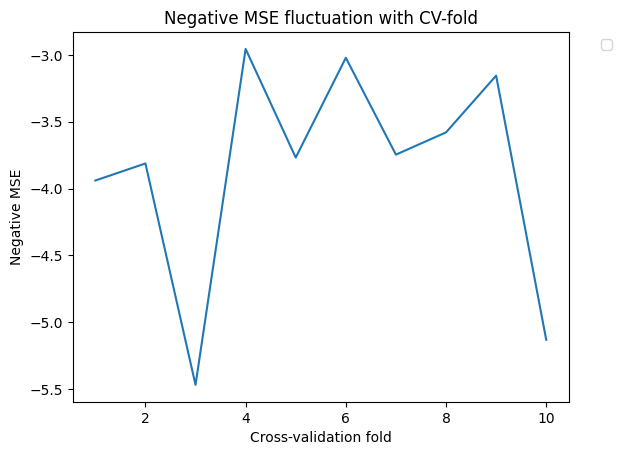

In [153]:
plot_cv_scores(model_pipeline = best_ridge_model, model_type = 'Ridge', cv_fold = 10)

R-squared: -2.647230625152588
Mean Squared Error (MSE): 91.88675689697266
Root Mean Squared Error (RMSE): 9.585758024119567


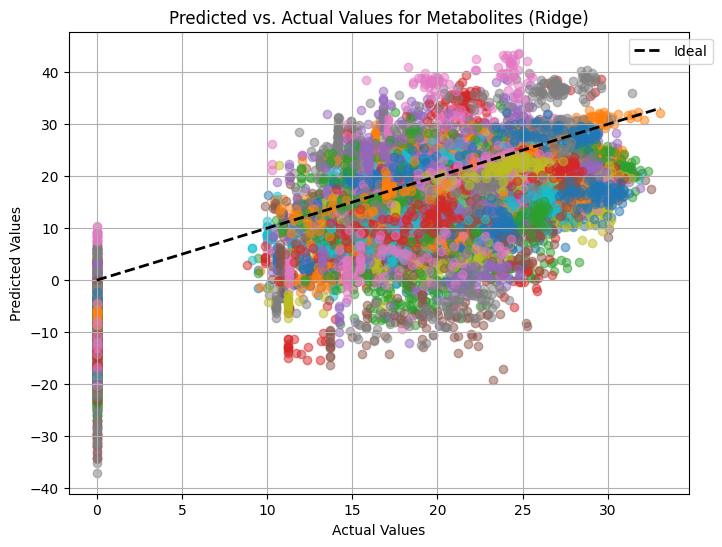

In [154]:
get_r2_mse_rmse_plot_pred(data_y_test = y_test, model_predictions = ridge_predictions, model_type = 'Ridge')

Cross-validation R-squared scores: [0.87669331 0.86068308 0.85070312 0.87165046 0.88742834 0.8667019
 0.84369165 0.82829857 0.86113822 0.86958927]
Average R-squared score: 0.8616577923297882


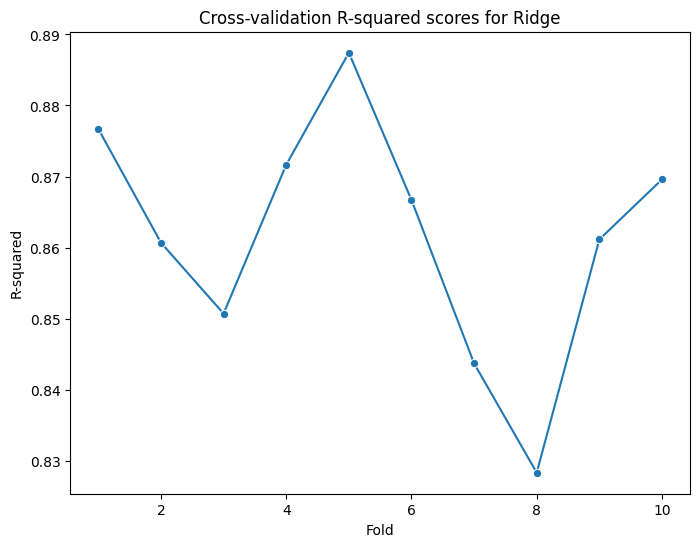

In [155]:
get_r2_cross_val(model = best_ridge_model, model_name = 'Ridge')

In [156]:
get_metrics(y_predicted = ridge_predictions)

MSE: 91.88675689697266
MAE: 7.730861663818359
MedAE: 7.046121801880012
Mean absolute percentage error: inf


/tmp/ipython-input-1747444863.py:18: RuntimeWarning: divide by zero encountered in divide
  return np.mean(np.abs((y_true - y_pred) / y_true)) * 100


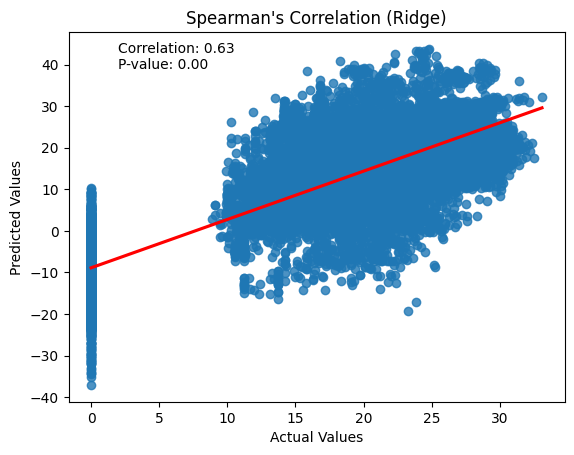

In [157]:
get_spearman_correlation(model_predictions = ridge_predictions, model_name = 'Ridge')

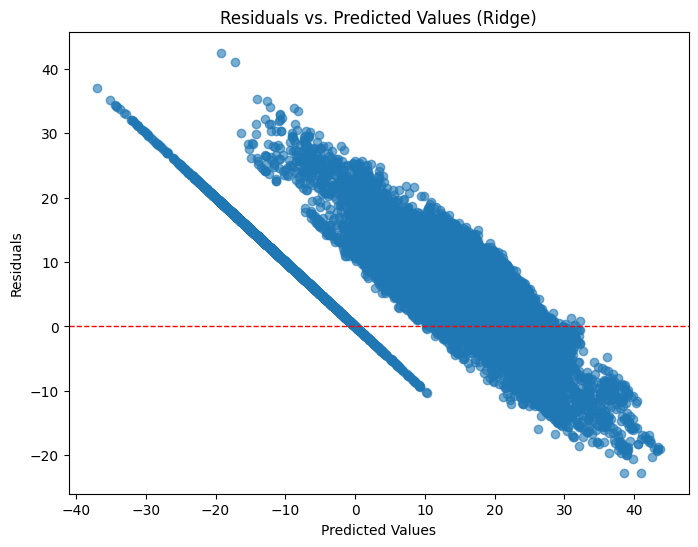

In [158]:
get_residuals_vs_pred_plot(model_predictions = ridge_predictions, model_name = 'Ridge')

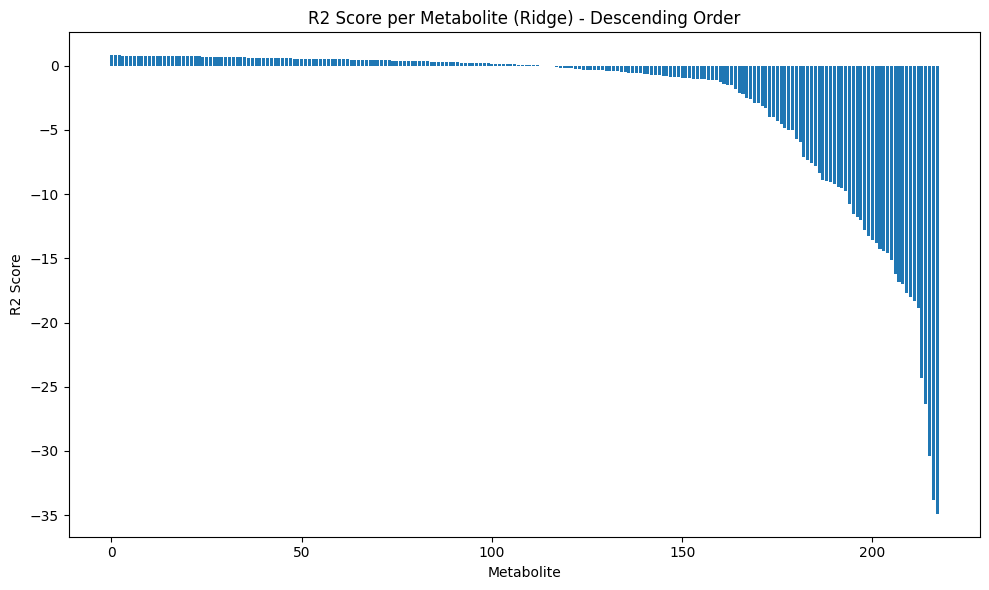

In [159]:
plot_r2_per_metabolite(best_ridge_model, "Ridge", X_test, y_test)

In [160]:
r2_ridge = get_r2_per_metabolite(best_ridge_model, 'Ridge', X_test, y_test)
r2_ridge

,Metabolite,R2 Score
109,glycerol,0.815551
9,1-palmitoylglycerol (1-monopalmitin),0.809697
200,threonate,0.798976
15,1-stearoyl-GPI (18:0),0.788074
81,docosadienoate (22:2n6),0.787143
...,...,...
189,serine,-24.317365
66,cholesterol,-26.330659
113,glycine,-30.409856
23,2-hydroxyglutarate,-33.826033


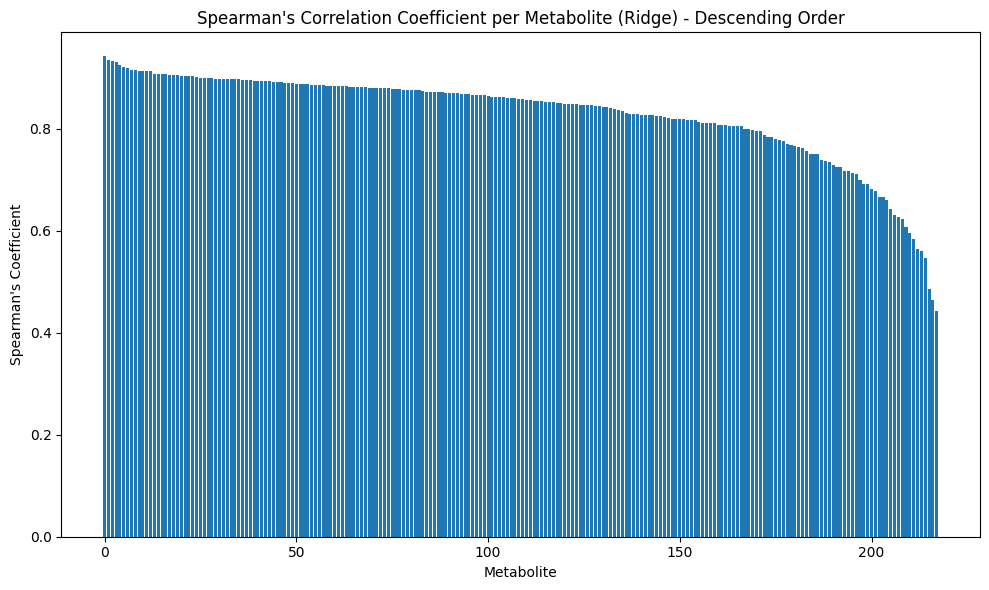

In [161]:
plot_spearman_per_metabolite(best_ridge_model, 'Ridge', X_test, y_test)

In [162]:
spearman_ridge = get_spearman_per_metabolite(best_ridge_model, 'Ridge', X_test, y_test)
spearman_ridge

,Metabolite,Spearman Coefficient
120,hippurate,0.942160
59,beta-alanine,0.935300
159,1-methyladenosine,0.933062
175,phenylacetylglutamine,0.930771
212,xanthine,0.925056
...,...,...
142,mannose,0.559557
147,myo-inositol,0.546476
216,pyruvate,0.485973
215,dehydroascorbate,0.464220


In [163]:
# r2_ridge.to_csv(f'{results_path}/r2_ridge.csv', index = False)

In [164]:
# spearman_ridge.to_csv(f'{results_path}/spearman_ridge.csv', index = False)

#Multi-task Lasso

In [102]:
pipeline_multi_lasso = Pipeline([
                                ('imputer', SimpleImputer(strategy='mean')),
                                ('scaler', StandardScaler()),
                                ('pca', PCA(0.95,)),
                                ('model', MultiTaskLasso(random_state = 0))
                                ])

In [103]:
param_grid_lasso = {
                    'model__alpha': [0.001, 0.01, 0.1, 1, 10, 100] # Example values for alpha
                   }

grid_search_lasso = GridSearchCV(pipeline_multi_lasso, param_grid_lasso, cv=10, scoring='neg_mean_squared_error', n_jobs = -1)
grid_search_lasso.fit(X_train, y_train)

GridSearchCV(cv=10,
             estimator=Pipeline(steps=[('imputer', SimpleImputer()),
                                       ('scaler', StandardScaler()),
                                       ('pca', PCA(n_components=0.95)),
                                       ('model',
                                        MultiTaskLasso(random_state=0))]),
             n_jobs=-1,
             param_grid={'model__alpha': [0.001, 0.01, 0.1, 1, 10, 100]},
             scoring='neg_mean_squared_error')

In [104]:
print("Best hyperparameters:", grid_search_lasso.best_params_)
print("Best score:", grid_search_lasso.best_score_)

Best hyperparameters: {'model__alpha': 1}
Best score: -4.134573674201965


In [105]:
best_lasso_model = grid_search_lasso.best_estimator_

In [106]:
lasso_predictions = best_lasso_model.predict(X_test)

In [107]:
# save_model(model = best_lasso_model, model_name = 'Lasso')

Cross-validation scores: [-3.89741609 -3.81716077 -5.41637185 -2.97056498 -3.84990416 -2.99399485
 -3.77643269 -3.60879944 -3.06375125 -5.16537518]
Average score: -3.8559771250644346


/tmp/ipython-input-3942901263.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')


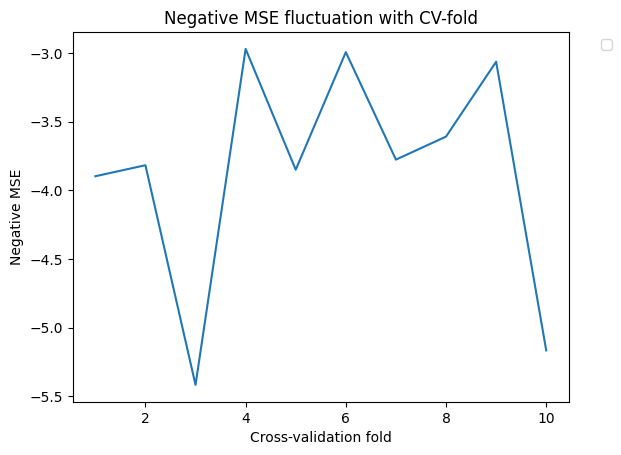

In [108]:
plot_cv_scores(model_pipeline = best_lasso_model, model_type = 'Multi-task Lasso', cv_fold = 10)

R-squared: -3.012471914291382
Mean Squared Error (MSE): 108.42194366455078
Root Mean Squared Error (RMSE): 10.412585829876784


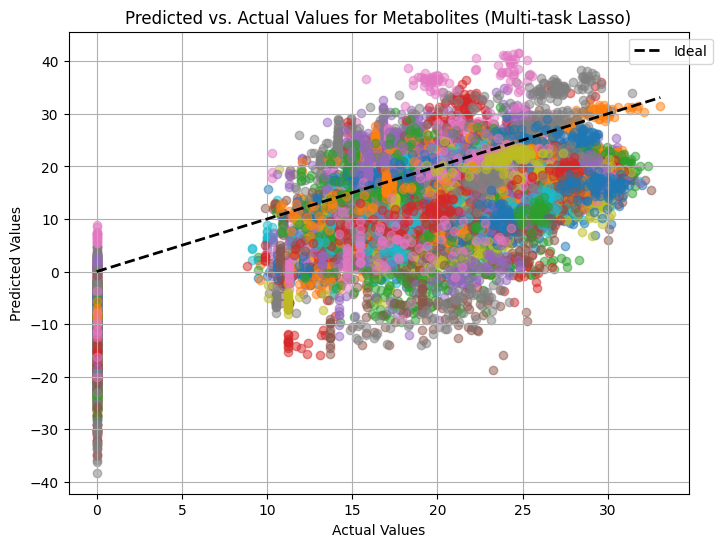

In [109]:
get_r2_mse_rmse_plot_pred(data_y_test = y_test, model_predictions = lasso_predictions, model_type = 'Multi-task Lasso')

Cross-validation R-squared scores: [0.87761784 0.86106426 0.84999222 0.87295961 0.88867414 0.86856067
 0.84552479 0.82741356 0.86025065 0.87193269]
Average R-squared score: 0.8623990416526794


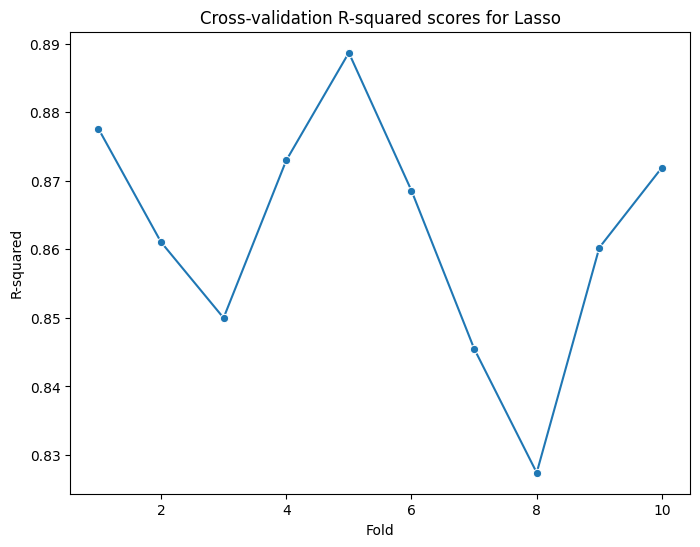

In [110]:
get_r2_cross_val(model = best_lasso_model, model_name = 'Lasso')

In [111]:
get_metrics(y_predicted = lasso_predictions)

MSE: 108.42194366455078
MAE: 8.623446464538574
MedAE: 7.887660503072785
Mean absolute percentage error: inf


/tmp/ipython-input-1747444863.py:18: RuntimeWarning: divide by zero encountered in divide
  return np.mean(np.abs((y_true - y_pred) / y_true)) * 100


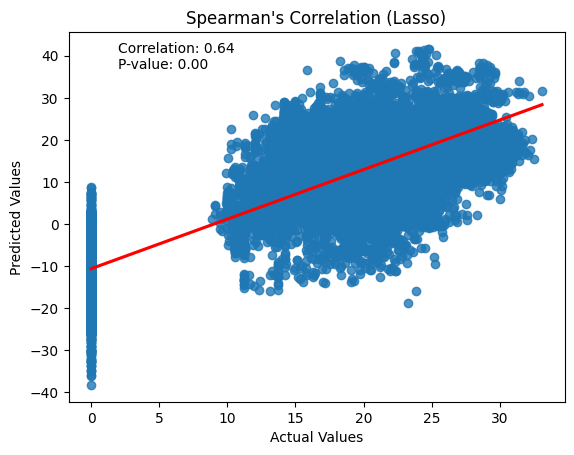

In [112]:
get_spearman_correlation(model_predictions = lasso_predictions, model_name = 'Lasso')

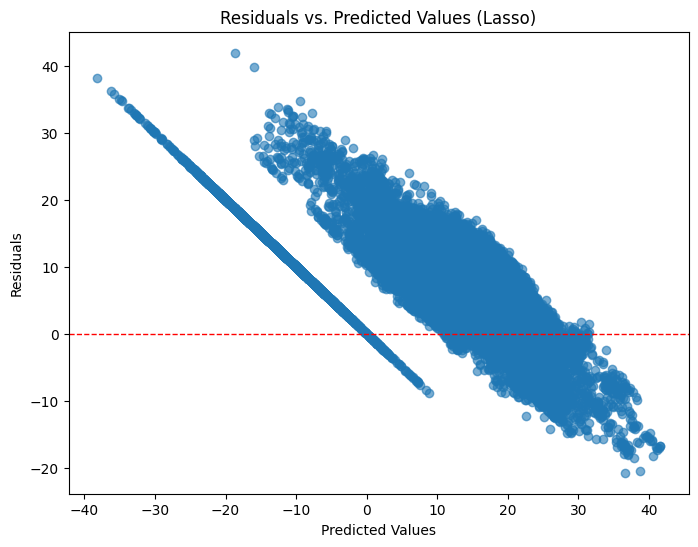

In [113]:
get_residuals_vs_pred_plot(model_predictions = lasso_predictions, model_name = 'Lasso')

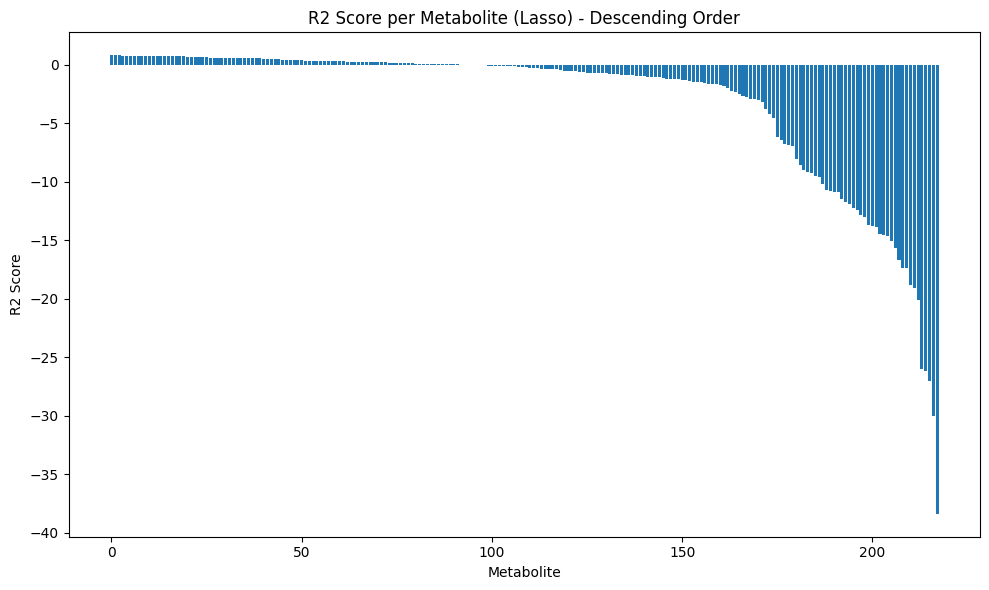

In [114]:
plot_r2_per_metabolite(best_lasso_model, "Lasso", X_test, y_test)

In [115]:
r2_lasso = get_r2_per_metabolite(best_lasso_model, 'Lasso', X_test, y_test)
r2_lasso

,Metabolite,R2 Score
126,inositol 1-phosphate (I1P),0.811841
0,"1,5-anhydroglucitol (1,5-AG)",0.802424
118,heme,0.798276
129,isovalerylcarnitine,0.786862
109,glycerol,0.784496
...,...,...
66,cholesterol,-25.974649
189,serine,-26.206006
113,glycine,-27.050228
23,2-hydroxyglutarate,-30.059766


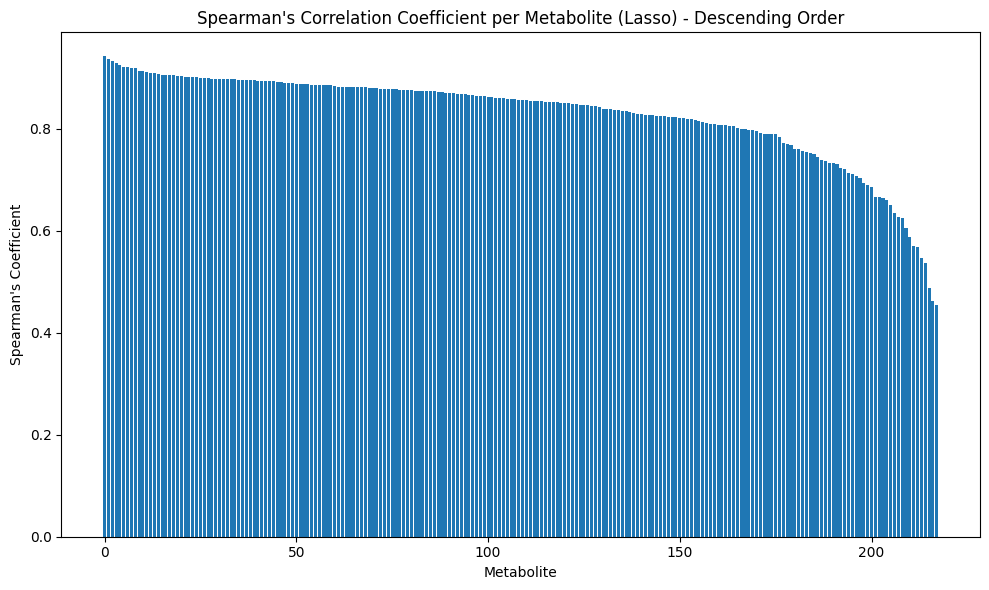

In [116]:
plot_spearman_per_metabolite(best_lasso_model, 'Lasso', X_test, y_test)

In [117]:
spearman_lasso = get_spearman_per_metabolite(best_lasso_model, 'Lasso', X_test, y_test)
spearman_lasso

,Metabolite,Spearman Coefficient
120,hippurate,0.941527
59,beta-alanine,0.935403
159,1-methyladenosine,0.932326
175,phenylacetylglutamine,0.929232
212,xanthine,0.923800
...,...,...
147,myo-inositol,0.547259
142,mannose,0.536742
216,pyruvate,0.486870
215,dehydroascorbate,0.462947


In [118]:
# r2_lasso.to_csv(f'{results_path}/r2_lasso.csv', index = False)
# spearman_lasso.to_csv(f'{results_path}/spearman_lasso.csv', index = False)

#Multi-task Elastic-Net

In [119]:
pipeline_elasticnet = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler()),
    ('pca', PCA(0.95)),
    ('model', MultiTaskElasticNet(random_state = 0))
])

In [120]:
param_grid_elasticnet = {
    'model__alpha': [0.001, 0.01, 0.1, 1, 10, 100],
    'model__l1_ratio': [0.1, 0.5, 0.9]
}

In [121]:
grid_search_elasticnet = GridSearchCV(
                                      pipeline_elasticnet,
                                      param_grid_elasticnet,
                                      cv=10,
                                      scoring='neg_mean_squared_error',
                                      n_jobs = -1
                                      )
grid_search_elasticnet.fit(X_train, y_train)

GridSearchCV(cv=10,
             estimator=Pipeline(steps=[('imputer', SimpleImputer()),
                                       ('scaler', StandardScaler()),
                                       ('pca', PCA(n_components=0.95)),
                                       ('model',
                                        MultiTaskElasticNet(random_state=0))]),
             n_jobs=-1,
             param_grid={'model__alpha': [0.001, 0.01, 0.1, 1, 10, 100],
                         'model__l1_ratio': [0.1, 0.5, 0.9]},
             scoring='neg_mean_squared_error')

In [122]:
print("Best hyperparameters for ElasticNet:", grid_search_elasticnet.best_params_)
print("Best score for ElasticNet:", grid_search_elasticnet.best_score_)

Best hyperparameters for ElasticNet: {'model__alpha': 1, 'model__l1_ratio': 0.9}
Best score for ElasticNet: -4.139465355873108


In [123]:
best_elasticnet_model = grid_search_elasticnet.best_estimator_

In [124]:
elasticnet_predictions = best_elasticnet_model.predict(X_test)

In [125]:
# save_model(model = best_elasticnet_model, model_name = 'ElasticNet')

Cross-validation scores: [-3.91556581 -3.83381083 -5.4208033  -2.99826831 -3.83725925 -3.00638614
 -3.79167838 -3.61416289 -3.08499314 -5.16445757]
Average score: -3.8667385622055135


/tmp/ipython-input-3942901263.py:21: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')


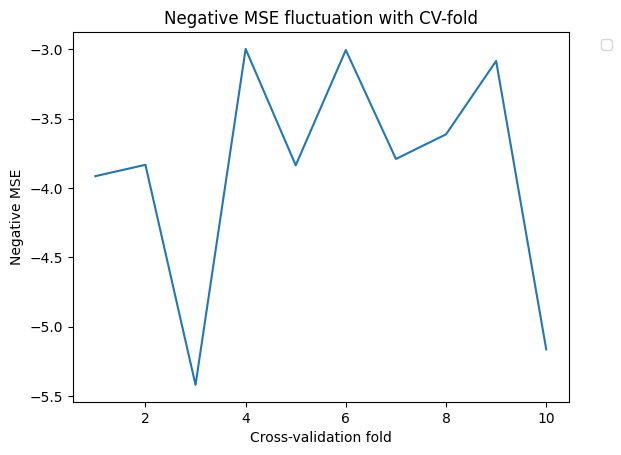

In [126]:
plot_cv_scores(model_pipeline = best_elasticnet_model, model_type = 'Multi-task Elastic Net (All metabolites)', cv_fold = 10)

R-squared: -2.822817087173462
Mean Squared Error (MSE): 102.14960479736328
Root Mean Squared Error (RMSE): 10.106908765659423


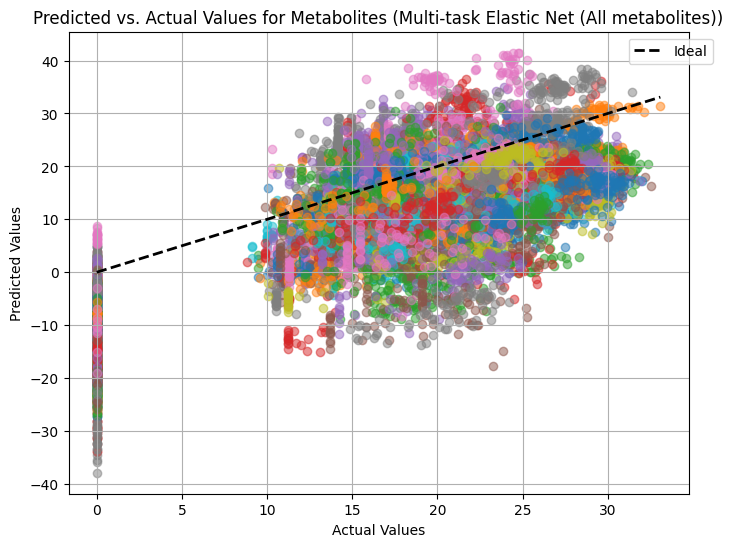

In [127]:
get_r2_mse_rmse_plot_pred(data_y_test = y_test, model_predictions = elasticnet_predictions, model_type = 'Multi-task Elastic Net (All metabolites)')

Cross-validation R-squared scores: [0.87759101 0.86294508 0.84964305 0.87249726 0.88779634 0.86865568
 0.84496987 0.82788801 0.8609612  0.87128037]
Average R-squared score: 0.862422788143158


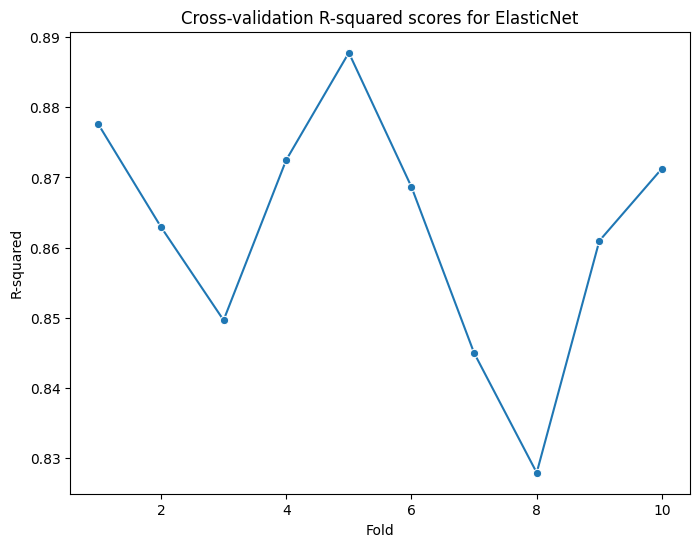

In [128]:
get_r2_cross_val(model = best_elasticnet_model, model_name = 'ElasticNet')

In [129]:
get_metrics(y_predicted = elasticnet_predictions)

MSE: 102.14960479736328
MAE: 8.336356163024902
MedAE: 7.609529853932553
Mean absolute percentage error: inf


/tmp/ipython-input-1747444863.py:18: RuntimeWarning: divide by zero encountered in divide
  return np.mean(np.abs((y_true - y_pred) / y_true)) * 100


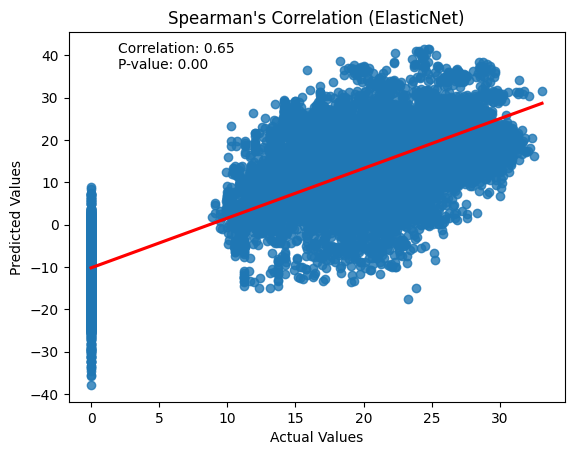

In [130]:
get_spearman_correlation(model_predictions = elasticnet_predictions, model_name = 'ElasticNet')

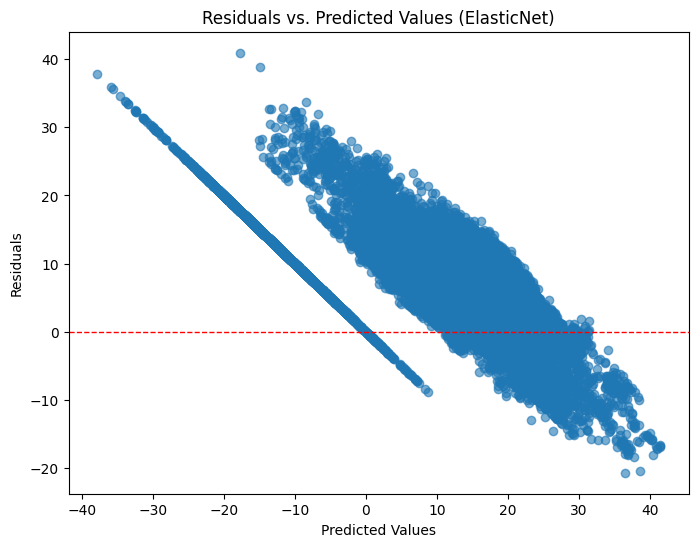

In [131]:
get_residuals_vs_pred_plot(model_predictions = elasticnet_predictions, model_name = 'ElasticNet')

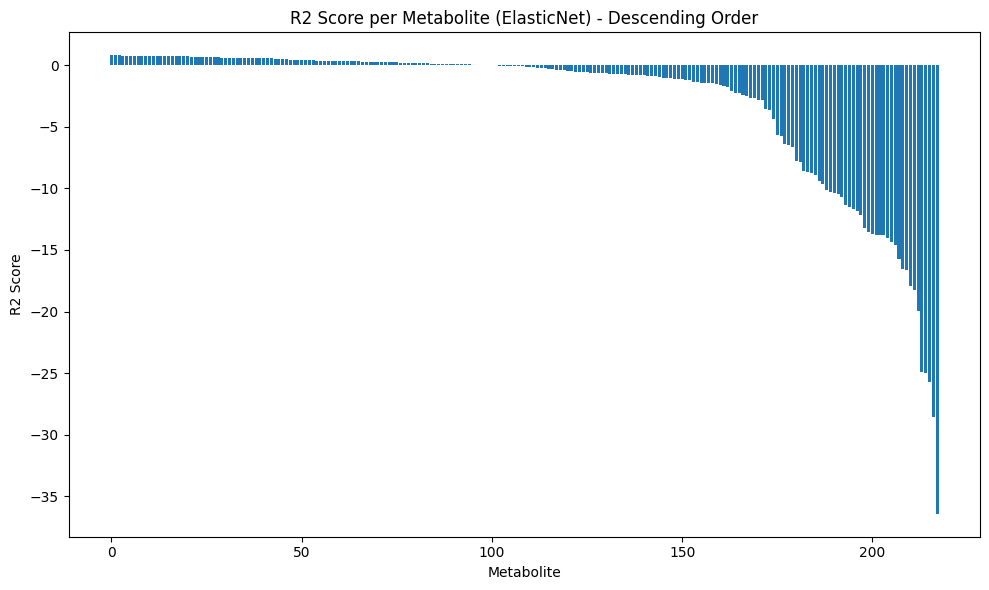

In [132]:
plot_r2_per_metabolite(best_elasticnet_model, "ElasticNet", X_test, y_test)

In [133]:
# y_test.to_csv(f'{results_path}/y_test_elasticnet_model.csv', index = True)

In [134]:
elasticnet_predictions = pd.DataFrame(elasticnet_predictions, index = y_test.index, columns = y_test.columns)
elasticnet_predictions

,"1,5-anhydroglucitol (1,5-AG)",1-arachidonoyl-GPC (20:4n6),1-arachidonoyl-GPE (20:4n6),1-arachidonoyl-GPI (20:4),1-linoleoylglycerol (18:2),1-linoleoyl-GPC (18:2),1-oleoylglycerol (1-monoolein),1-oleoyl-GPE (18:1),1-palmitoleoyl-GPC (16:1),1-palmitoylglycerol (1-monopalmitin),...,urea,uridine,valine,valylglycine,xanthine,xanthosine,3-phosphoglycerate,dehydroascorbate,pyruvate,phosphoenolpyruvate (PEP)
MSKC-00487,24.191486,25.261040,16.187019,20.719625,17.879808,21.290009,18.292395,22.872543,14.771257,21.745420,...,22.495506,10.748848,15.566092,14.665170,8.635671,11.728258,-1.547297,-9.794516,-0.285315,-7.819593
CORN-01899,22.254801,22.173035,11.445652,16.260496,11.906162,16.170622,12.243513,15.952579,11.960176,17.170107,...,20.064125,4.575266,10.883465,11.321069,-0.201361,8.187929,-7.253162,-11.279856,1.043121,-29.876207
DIAG-16132,23.712671,23.110401,14.087049,17.934822,14.314260,18.196703,13.983554,18.484688,13.784379,18.993925,...,20.884254,9.724023,13.398593,15.791121,7.235686,8.856281,-5.796341,-18.707701,-6.899870,-12.737551
MSKC-00463,21.730656,23.862404,16.105808,19.810455,17.663736,18.855743,18.031757,20.681627,13.759396,21.135139,...,21.236937,8.653488,16.087914,13.096953,6.074479,11.039631,-1.916098,-5.258450,2.919996,-8.768948
C3N-01364,-6.477497,-2.909280,18.163452,-10.008080,-12.499297,-10.387674,-13.883045,-9.507933,-11.882463,-11.100872,...,13.378444,-22.708109,10.764696,-7.956471,-24.307669,-15.715329,0.575951,-7.973360,3.565545,-8.046820
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
C3N-00662,-5.928915,-1.987481,16.939505,-8.018198,-11.464702,-9.762520,-12.650417,-8.528137,-11.347406,-9.771423,...,13.072212,-22.361582,10.762550,-8.323571,-24.524176,-14.615857,-1.529448,-5.605701,6.706580,-11.834387
C3L-02041,-6.077789,-1.943080,18.034712,-8.090282,-10.912454,-9.267645,-12.113733,-8.253021,-11.254467,-9.435856,...,13.716440,-21.493399,12.222008,-7.687375,-22.940584,-14.231645,1.907373,-2.755663,9.591677,-7.646887
CORN-01632,23.681767,22.878519,9.790811,16.271074,11.627947,16.601723,12.241814,16.555534,12.858123,17.253672,...,20.605455,4.445827,10.035887,12.238866,-0.287493,9.253811,-7.855339,-12.789764,1.023988,-34.574913
MSKC-00272,23.956915,23.934593,18.930779,20.879389,17.011772,19.537209,16.751923,20.909874,13.691478,21.610601,...,21.755161,14.206148,17.397396,15.811688,11.256905,11.557676,1.037123,-4.400681,8.681426,-6.004116


In [135]:
# elasticnet_predictions.to_csv(f'{results_path}/predictions_elasticnet_model.csv', index = True)

In [136]:
r2_elastic = get_r2_per_metabolite(best_elasticnet_model, 'ElasticNet', X_test, y_test)
r2_elastic

,Metabolite,R2 Score
126,inositol 1-phosphate (I1P),0.816262
118,heme,0.803726
0,"1,5-anhydroglucitol (1,5-AG)",0.800928
129,isovalerylcarnitine,0.794675
109,glycerol,0.791805
...,...,...
189,serine,-24.914298
66,cholesterol,-24.993242
113,glycine,-25.753379
23,2-hydroxyglutarate,-28.567054


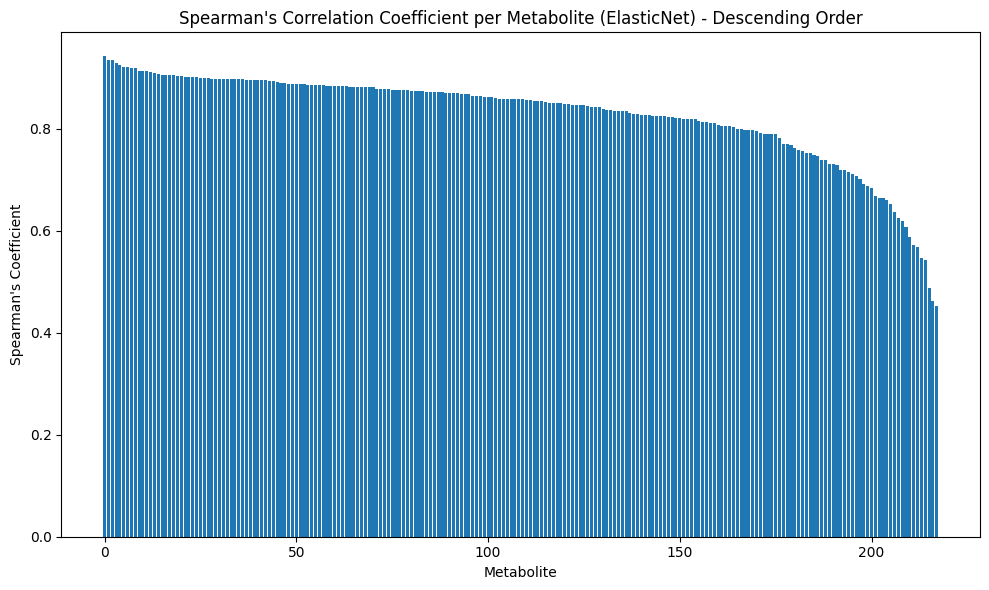

In [137]:
plot_spearman_per_metabolite(best_elasticnet_model, 'ElasticNet', X_test, y_test)

In [138]:
spearman_elastic = get_spearman_per_metabolite(best_elasticnet_model, 'ElasticNet', X_test, y_test)
spearman_elastic

,Metabolite,Spearman Coefficient
120,hippurate,0.941407
159,1-methyladenosine,0.935057
59,beta-alanine,0.934941
175,phenylacetylglutamine,0.929198
212,xanthine,0.925013
...,...,...
142,mannose,0.547026
147,myo-inositol,0.541352
216,pyruvate,0.487075
215,dehydroascorbate,0.461990


In [139]:
# r2_elastic.to_csv(f'{results_path}/r2_elastic.csv', index = False)
# spearman_elastic.to_csv(f'{results_path}/spearman_elastic.csv', index = False)